#### Data Explore "New Car Registration by Make" from data.gov.sg

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("NewRegistrationofCarsbyMake.csv")

print(df.tail())

         month   make importer_type                  fuel_type  \
51664  2025-05  VOLVO           AMD            Petrol-Electric   
51665  2025-05  VOLVO           AMD  Petrol-Electric (Plug-In)   
51666  2025-05  VOLVO           AMD                   Electric   
51667  2025-05  XPENG           AMD                   Electric   
51668  2025-05  ZEEKR           AMD                   Electric   

             vehicle_type  number  
51664  Coupe/ Convertible     NaN  
51665  Coupe/ Convertible     NaN  
51666  Coupe/ Convertible     NaN  
51667  Coupe/ Convertible     NaN  
51668  Coupe/ Convertible     NaN  


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51669 entries, 0 to 51668
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   month          51669 non-null  object 
 1   make           51669 non-null  object 
 2   importer_type  20514 non-null  object 
 3   fuel_type      51669 non-null  object 
 4   vehicle_type   51669 non-null  object 
 5   number         22206 non-null  float64
dtypes: float64(1), object(5)
memory usage: 2.4+ MB


In [3]:
df["month"]

0        2016-01
1        2016-01
2        2016-01
3        2016-01
4        2016-01
          ...   
51664    2025-05
51665    2025-05
51666    2025-05
51667    2025-05
51668    2025-05
Name: month, Length: 51669, dtype: object

In [4]:
# Count all fuel type from YR2022 to YR2024

count_all = df["fuel_type"].value_counts()

print("=== Vehicle Count by Fuel Type (2016-01 to 2025-05) ===")
print(count_all)

=== Vehicle Count by Fuel Type (2016-01 to 2025-05) ===
fuel_type
Petrol                       26848
Electric                      6114
Diesel                        5881
Others                        5770
Petrol-Electric               4824
Petrol-Electric (Plug-In)     2154
Diesel-Electric                 60
Diesel-Electric (Plug-In)       18
Name: count, dtype: int64


In [5]:
# Take note for EV, it includes "Petrol-Electric (Plug-In)", "Electric" and "Diesel-Electric (Plug-In)" 
# The classification of fuel type starts from YR2022 onwards.

df["fuel_type"].unique()

array(['Petrol', 'Diesel', 'Others', 'Petrol-Electric',
       'Petrol-Electric (Plug-In)', 'Electric',
       'Diesel-Electric (Plug-In)', 'Diesel-Electric'], dtype=object)

In [6]:
# Define EV and Non-EV in SG

ev_df = df[
    df["fuel_type"].isin([
        "Electric",
        "Petrol-Electric (Plug-In)",
        "Diesel-Electric (Plug-In)"
    ])
]

n_ev_df = df[
    df["fuel_type"].isin([
        "Petrol",
        "Diesel",
        "Petrol-Electric",
        "Diesel-Electric",
        "Others"
    ])
]

print(ev_df)
print(n_ev_df)
print()

         month        make importer_type                  fuel_type  \
27918  2022-07        AUDI           NaN  Petrol-Electric (Plug-In)   
27919  2022-07        AUDI           NaN                   Electric   
27922  2022-07      B.M.W.           NaN  Petrol-Electric (Plug-In)   
27923  2022-07      B.M.W.           NaN                   Electric   
27925  2022-07     BLUECAR           NaN                   Electric   
...        ...         ...           ...                        ...   
51662  2025-05  VOLKSWAGEN           AMD                   Electric   
51665  2025-05       VOLVO           AMD  Petrol-Electric (Plug-In)   
51666  2025-05       VOLVO           AMD                   Electric   
51667  2025-05       XPENG           AMD                   Electric   
51668  2025-05       ZEEKR           AMD                   Electric   

             vehicle_type  number  
27918           Hatchback     NaN  
27919           Hatchback     2.0  
27922           Hatchback     NaN  
279

In [16]:
ev_by_month = (
     ev_df   # fuel_type: Electric, Petrol/Diesel-Electric (Plug-In)
    .groupby("month")["number"]
    .sum()
    .astype(int)
    .reset_index(name="count")
)
n_ev_by_month = (
     n_ev_df   # fuel_type: Petrol/Petrol-Electric, Diesel/Diesel-Electric and Others
    .groupby("month")["number"]
    .sum()
    .astype(int)
    .reset_index(name="count")
)

ev_non_ev_by_month = pd.merge(
    ev_by_month,
    n_ev_by_month,
    on="month"
).fillna(0)

print("                EV   &  Non-EV:")
print(ev_non_ev_by_month)

                EV   &  Non-EV:
      month  count_x  count_y
0   2022-07      311     2218
1   2022-08      297     2077
2   2022-09      443     1914
3   2022-10      408     1988
4   2022-11      367     1942
5   2022-12      423     1984
6   2023-01      289     1599
7   2023-02      260     1876
8   2023-03      312     2157
9   2023-04      332     1853
10  2023-05      394     1820
11  2023-06      451     1881
12  2023-07      504     1878
13  2023-08      605     1936
14  2023-09      562     1849
15  2023-10      457     1895
16  2023-11      581     1960
17  2023-12      987     3787
18  2024-01      646     1594
19  2024-02      763     1651
20  2024-03     1215     2293
21  2024-04     1225     2227
22  2024-05     1049     2139
23  2024-06     1217     2557
24  2024-07     1219     2698
25  2024-08     1433     2516
26  2024-09     1329     2796
27  2024-10     1200     2207
28  2024-11     1322     2284
29  2024-12     2040     3402
30  2025-01     1064     1639
31  2025

In [9]:
# Construct year column for analysis

df["month"] = pd.to_datetime(df["month"], format="%Y-%m")
df["year"] = df["month"].dt.year

In [10]:
# Check yearly

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51669 entries, 0 to 51668
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   month          51669 non-null  datetime64[ns]
 1   make           51669 non-null  object        
 2   importer_type  20514 non-null  object        
 3   fuel_type      51669 non-null  object        
 4   vehicle_type   51669 non-null  object        
 5   number         22206 non-null  float64       
 6   year           51669 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(4)
memory usage: 2.6+ MB


In [11]:
# Classify each row as EV or Non-EV
df["ev_category"] = df["fuel_type"].isin([
    "Electric",
    "Petrol-Electric (Plug-In)",
    "Diesel-Electric (Plug-In)"
]).map({True: "EV", False: "Non-EV"})

# Count EV and Non-EV registrations by year
ev_non_ev_by_year = (
    df.groupby(["year", "ev_category"])["number"]
      .sum()
      .unstack(fill_value=0)
      .reset_index()
)

print(ev_non_ev_by_year)

ev_category  year       EV   Non-EV
0            2016      0.0  87504.0
1            2017      0.0  91922.0
2            2018      0.0  80281.0
3            2019      0.0  72344.0
4            2020      0.0  44465.0
5            2021      0.0  45442.0
6            2022   2249.0  28690.0
7            2023   5734.0  24491.0
8            2024  14658.0  28364.0
9            2025   7996.0  11322.0


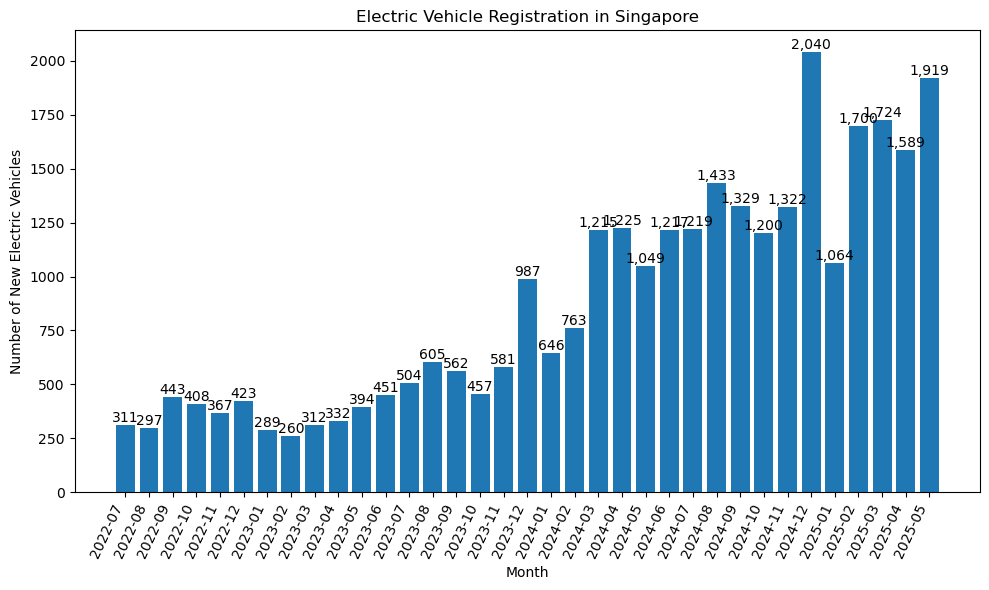

In [12]:
# Plot the bar chart

import matplotlib.pyplot as plt

ev = (
    ev_df
    .groupby("month")["number"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    ev["month"].astype(str),
    ev["number"]
)

plt.xlabel("Month")
plt.ylabel("Number of New Electric Vehicles")
plt.title("Electric Vehicle Registration in Singapore")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom")
    plt.xticks(rotation=65, ha='right')

plt.tight_layout()
plt.show()

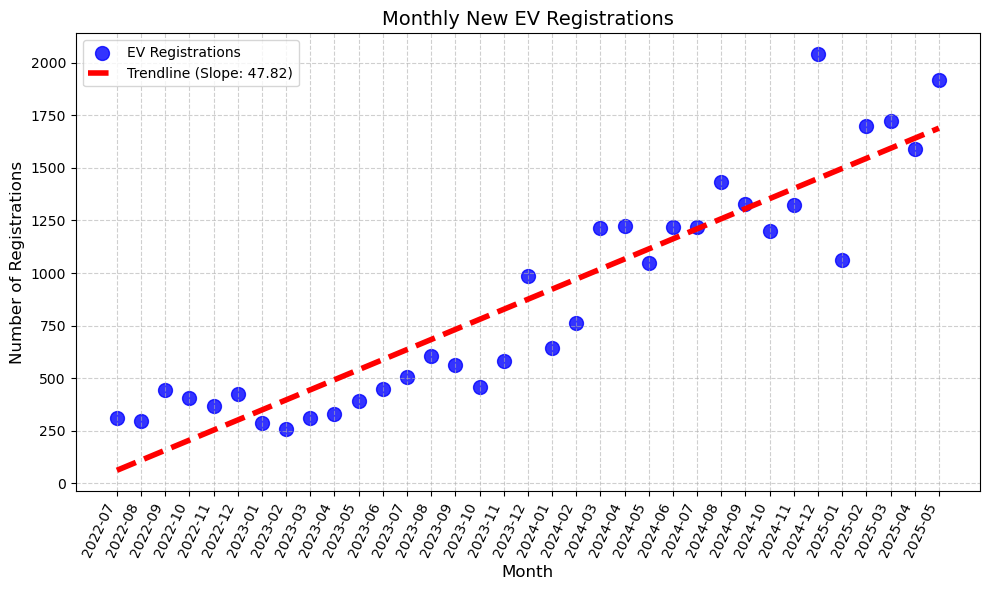

In [41]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# 1. Extract X and Y data
x_data = ev_by_month["month"]
y_data = ev_by_month["count"]

# 2. Create numerical indices for the X-axis calculation
x_indices = np.arange(len(x_data))

# 3. Calculate the linear trendline (degree 1 polynomial: y = mx + c)
slope, intercept = np.polyfit(x_indices, y_data, 1)
trendline = slope * x_indices + intercept

# Plot EV scatter points
plt.scatter(
    x_data, y_data, 
    color="blue", label="EV Registrations", s=100, alpha=0.8
)

# 4. Plot the linear line
plt.plot(
    x_data, trendline, 
    color="red", linestyle="--", linewidth=4, 
    label=f"Trendline (Slope: {slope:.2f})"
)

plt.title("Monthly New EV Registrations", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Registrations", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=65, ha='right')

plt.tight_layout() # Prevents cut-off rotated X-axis labels
plt.show()
